# Quantum Tree Generator (QTG) for 0-1 Knapsack

implementation of the QTG algorithm from:
*"A quantum algorithm for solving 0-1 Knapsack problems"*,
Wilkening et al., npj Quantum Information (2025)

### 10-item instance

| Item | Weight | Profit | Density |
|:----:|:------:|:------:|:-------:|
|  0   |   2    |   6    |  3.00   |
|  1   |   3    |   8    |  2.67   |
|  2   |   4    |   10   |  2.50   |
|  3   |   5    |   11   |  2.20   |
|  4   |   3    |   6    |  2.00   |
|  5   |   6    |   10   |  1.67   |
|  6   |   7    |   11   |  1.57   |
|  7   |   4    |   6    |  1.50   |
|  8   |   8    |   10   |  1.25   |
|  9   |   5    |   5    |  1.00   |

Capacity = 20. Greedy takes items 0,1,2,3,4 (profit 41). Optimal is items 0,1,2,3,5 (profit 45).


In [21]:

import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.synthesis.qft import synth_qft_full
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit.visualization import plot_histogram

In [2]:
# ============================================================
# Cell 2 -- Problem setup
# ============================================================
#
# Items are pre-sorted by decreasing profit/weight density,
# as prescribed by the paper's classical preprocessing step.
#
# The greedy algorithm walks through the sorted list and takes
# each item if it still fits.  For this 10-item instance the greedy
# solution is SUB-OPTIMAL, which makes the problem interesting:
# the QTG + amplification must find a solution the greedy missed.


weights  = [2, 3, 4, 5, 3, 6, 7, 4, 8, 5]   # already sorted by density
profits  = [6, 8, 10, 11, 6, 10, 11, 6, 10, 5]
capacity = 20
n_items  = len(weights)        

# ---- Register sizing ----
#
# CAPACITY register (n_cap qubits):
#   Must hold values 0....c and allow the MSB sign trick.
#   Rule: 2^(n_cap-1) > capacity  AND  2^(n_cap-1) > max(weights).
#   capacity=20, max weight=8.  2^5 = 32 > 20 and 32 > 8.  So n_cap=6.
#
# PROFIT register (n_prof qubits):
#   The oracle subtracts the threshold and checks the MSB.
#   Rule: 2^(n_prof-1) > threshold.
#   Threshold will be 42 (greedy_profit+1).  2^6 = 64 > 42.  So n_prof=7.
#


n_cap  = 6    # 6 qubits for remaining capacity  (values 0..63)
n_prof = 7    # 7 qubits for accumulated profit   (values 0..127)

# ---- Greedy solution ----
# Walk through sorted items, take each if it fits:
#   item 0 (w=2): take, remaining = 18
#   item 1 (w=3): take, remaining = 15
#   item 2 (w=4): take, remaining = 11
#   item 3 (w=5): take, remaining = 6
#   item 4 (w=3): take, remaining = 3
#   item 5 (w=6): skip  (6 > 3)
#   item 6 (w=7): skip  (7 > 3)
#   item 7 (w=4): skip  (4 > 3)
#   item 8 (w=8): skip  (8 > 3)
#   item 9 (w=5): skip  (5 > 3)
# Greedy = [1,1,1,1,1,0,0,0,0,0], profit = 6+8+10+11+6 = 41

greedy_solution = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
greedy_profit   = 41

# Threshold: look for solutions strictly better than greedy.
threshold = greedy_profit + 1   # 42

# ---- Bias parameter (Eq. 5) ----
# Paper uses Delta=4, giving b = n/Delta = n/4.
#Δ tells the algorithm how far away, in number of changed 
# item choices, a promising solution is expected to be from 
# the current one; they set Δ=4 because that tuning worked well in practice.

b = n_items / 4   # 2.5

print(f'Items (sorted):  weights={weights}, profits={profits}')
print(f'Capacity: {capacity}')
print(f'Greedy: {greedy_solution}  profit={greedy_profit}')
print(f'Threshold: profit >= {threshold}')
print(f'Bias b = {b}')
print(f'Registers: n_cap={n_cap}, n_prof={n_prof}')
print(f'Total qubits: {n_items}+{n_cap}+{n_prof}+1 = {n_items+n_cap+n_prof+1}')


Items (sorted):  weights=[2, 3, 4, 5, 3, 6, 7, 4, 8, 5], profits=[6, 8, 10, 11, 6, 10, 11, 6, 10, 5]
Capacity: 20
Greedy: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]  profit=41
Threshold: profit >= 42
Bias b = 2.5
Registers: n_cap=6, n_prof=7
Total qubits: 10+6+7+1 = 24


In [3]:
# ============================================================
# Cell 3 -- Biased Ry angles  (Eq. 3 of the paper)
# ============================================================
#
# For each item m, the QTG applies a BIASED Ry rotation
# (not a balanced Hadamard) whose angle depends on whether
# the greedy solution took that item.
#
# greedy_bit = 1  (greedy took item m):
#   theta = 2*arccos( sqrt(1/(2+b)) )
#   P(include) = (1+b)/(2+b)   -- favours inclusion
#   P(exclude) =   1  /(2+b)
#
# greedy_bit = 0  (greedy skipped item m):
#   theta = 2*arccos( sqrt((1+b)/(2+b)) )
#   P(include) =   1  /(2+b)   -- favours exclusion
#   P(exclude) = (1+b)/(2+b)
#
# Effect: paths close (in Hamming distance) to the greedy
# solution get higher amplitude, giving amplification a head
# start.  For this instance the optimal [0,1,1,0] is at
# Hamming distance 4 from the greedy [1,0,0,1], so it starts
# with very low amplitude -- exactly the scenario where Grover
# amplification shines.

def ry_angle(greedy_bit, b):
    """Biased Ry angle for one item"""
    if greedy_bit == 0:
        return 2 * np.arccos(np.sqrt((1 + b) / (2 + b)))
    else:
        return 2 * np.arccos(np.sqrt(1 / (2 + b)))

# Show the angles and probabilities for each item in the greedy solution
for m in range(n_items):
    theta = ry_angle(greedy_solution[m], b)
    p_inc = np.sin(theta / 2) ** 2   # probability calculation for inc. or exc.
    print(f'Item {m}: w={weights[m]}, p={profits[m]}, '
          f'greedy={greedy_solution[m]}, '
          f'theta={theta:.4f}, '
          f'P(incl)={p_inc:.4f}, P(excl)={1-p_inc:.4f}')

Item 0: w=2, p=6, greedy=1, theta=2.1598, P(incl)=0.7778, P(excl)=0.2222
Item 1: w=3, p=8, greedy=1, theta=2.1598, P(incl)=0.7778, P(excl)=0.2222
Item 2: w=4, p=10, greedy=1, theta=2.1598, P(incl)=0.7778, P(excl)=0.2222
Item 3: w=5, p=11, greedy=1, theta=2.1598, P(incl)=0.7778, P(excl)=0.2222
Item 4: w=3, p=6, greedy=1, theta=2.1598, P(incl)=0.7778, P(excl)=0.2222
Item 5: w=6, p=10, greedy=0, theta=0.9818, P(incl)=0.2222, P(excl)=0.7778
Item 6: w=7, p=11, greedy=0, theta=0.9818, P(incl)=0.2222, P(excl)=0.7778
Item 7: w=4, p=6, greedy=0, theta=0.9818, P(incl)=0.2222, P(excl)=0.7778
Item 8: w=8, p=10, greedy=0, theta=0.9818, P(incl)=0.2222, P(excl)=0.7778
Item 9: w=5, p=5, greedy=0, theta=0.9818, P(incl)=0.2222, P(excl)=0.7778


In [4]:
# ============================================================
# Cell 4 -- QFT gate helpers and Draper adders
# ============================================================
#

#
# The Draper adder adds a classical constant to a
# quantum register that is already in the Fourier basis.
# Each qubit j receives a phase  2*pi*a / 2^(j+1).
# Subtraction: just pass a negative value (phases wrap mod 2^n).

#do_swaps=False: A standard QFT requires a bunch of SWAP gates 
# at the very end to reverse the order of the qubits. 
# However, SWAP gates are expensive (they require 3 CNOT gates 
# each, which introduces a lot of noise on real hardware). 
# Because the Draper Adder only applies independent phase rotations 
# to each qubit, the physical order of the qubits doesn't matter. 
# By turning off the swaps, we save a massive amount of circuit depth 
# and reduce noise.

_qft_cache  = {}
_iqft_cache = {}

def qft_gate(n):
    """Return a QFT Gate for n qubits, cached."""
    if n not in _qft_cache:
        _qft_cache[n] = synth_qft_full(n, do_swaps=False).to_gate()
    return _qft_cache[n]

def iqft_gate(n):
    """Return an inverse-QFT Gate for n qubits, cached."""
    if n not in _iqft_cache:
        _iqft_cache[n] = qft_gate(n).inverse()
    return _iqft_cache[n]


def add_const_fourier(qc, reg, a):
    """Add integer a to register (already in Fourier basis)."""
    n = len(reg)
    for j in range(n):
        angle = 2 * pi * a / (2 ** (j + 1))
        qc.p(angle, reg[j])


def ctrl_add_const_fourier(qc, ctrl, reg, a):
    """Controlled add: add a iff control qubit is |1>."""
    n = len(reg)
    for j in range(n):
        angle = 2 * pi * a / (2 ** (j + 1))
        qc.cp(angle, ctrl, reg[j])

print('QFT helpers and Draper adders defined.')

QFT helpers and Draper adders defined.


In [5]:
# ============================================================
# Cell 5 -- Quantum comparator:  cap >= w?
# ============================================================
#
# Implements the C^2_{>= w_m} gate from Eq. 4.
#
# Algorithm:
#   1. QFT on cap register.
#   2. Subtract w  (add -w in Fourier basis).
#   3. Inverse QFT.  Now cap holds  (cap - w) mod 2^n_cap.
#   4. Inspect MSB:
#        MSB = 0  =>  result in [0, 2^(n-1)-1]  =>  cap >= w
#        MSB = 1  =>  result in [2^(n-1), 2^n-1] => cap < w
#      We want ancilla=1 when cap >= w, so:
#        X(MSB)  -- flip so MSB=0 becomes 1
#        CNOT(MSB -> ancilla)
#        X(MSB)  -- restore MSB
#   5. Restore cap register by adding w back.
#
# This circuit is self-inverse: calling it twice returns the
# ancilla to |0> and leaves cap unchanged.

def compare_geq(qc, cap_reg, ancilla, value, n_cap):
    """Set ancilla = ancilla XOR (cap_reg >= value)."""
    msb = n_cap - 1

    # subtract value
    qc.append(qft_gate(n_cap), cap_reg)
    add_const_fourier(qc, cap_reg, -value)
    qc.append(iqft_gate(n_cap), cap_reg)

    # read sign from MSB into ancilla
    qc.x(cap_reg[msb])
    qc.cx(cap_reg[msb], ancilla)
    qc.x(cap_reg[msb])

    # restore cap register
    qc.append(qft_gate(n_cap), cap_reg)
    add_const_fourier(qc, cap_reg, value)
    qc.append(iqft_gate(n_cap), cap_reg)

# Same function serves as its own uncomputation
uncompare_geq = compare_geq

print('Quantum comparator defined.')

Quantum comparator defined.


In [6]:
# ============================================================
# Cell 6 -- Build the QTG circuit  (Box 1 / Eq. 4 of paper)
# ============================================================
#
# The QTG is a cascade  G = U_1 . U_2 . ... . U_n.
# For each item m, the layer U_m has three sub-operations:
#
#   U^1_m : Check if cap >= w_m.  If yes, apply biased Ry on
#           path[m] to create a superposition of include/exclude.
#           If no, path[m] stays |0> (item forced out).
#
#   U^2_m : Controlled on path[m]=1, subtract w_m from cap.
#
#   U^3_m : Controlled on path[m]=1, add p_m to profit.
#
# Note: the capacity initialization (X gates to encode c)
# is inside the QTG circuit.  This means QTG maps |0...0> to
# the feasible superposition, and QTG^dag maps back to |0...0>.
# This fact determines the correct reflection state (all zeros).

def build_qtg(n_items, weights, profits, capacity, n_cap, n_prof,
              greedy_solution, b):
    total = n_items + n_cap + n_prof + 1
    qc = QuantumCircuit(total, name='QTG')

    # index ranges
    path_q = list(range(0, n_items))
    cap_q  = list(range(n_items, n_items + n_cap))
    prof_q = list(range(n_items + n_cap, n_items + n_cap + n_prof))
    anc_q  = n_items + n_cap + n_prof

    # ---- Initialize capacity register to c ----
    # Encode c in binary with LSB at index 0.
    # capacity=7 = 0111_2, so flip bits 0,1,2.
    
    for bit_idx in range(n_cap):
        if (capacity >> bit_idx) & 1:
            qc.x(cap_q[bit_idx])

    # ---- Process each item ----
    
    for m in range(n_items):
        theta = ry_angle(greedy_solution[m], b)
     
    #By calculating this theta and applying it to the circuit 
    # a few lines later (qc.cry(theta, anc_q, path_q[m])), 
    # the algorithm is doing that: The classical greedy algorithm 
    # is usually pretty close to the right answer. 
    # Let's start our quantum search heavily biased around the classical 
    # guess, rather than searching blindly from scratch.
    # This gives the amplitude amplification (Grover iterations) 
    # a massive head start!
    

        # U^1_m: biased superposition controlled on cap >= w_m
        compare_geq(qc, cap_q, anc_q, weights[m], n_cap)
        qc.cry(theta, anc_q, path_q[m])
        uncompare_geq(qc, cap_q, anc_q, weights[m], n_cap)

        # U^2_m: subtract w_m from cap, controlled on path[m]
        qc.append(qft_gate(n_cap), cap_q)
        ctrl_add_const_fourier(qc, path_q[m], cap_q, -weights[m])
        qc.append(iqft_gate(n_cap), cap_q)

        # U^3_m: add p_m to profit, controlled on path[m]
        qc.append(qft_gate(n_prof), prof_q)
        ctrl_add_const_fourier(qc, path_q[m], prof_q, profits[m])
        qc.append(iqft_gate(n_prof), prof_q)

    return qc

qtg_circ = build_qtg(n_items, weights, profits, capacity,
                      n_cap, n_prof, greedy_solution, b)

print(f'QTG built: {qtg_circ.num_qubits} qubits '
      f'(path:{n_items} + cap:{n_cap} + prof:{n_prof} + anc:1)')

#qtg_circ.draw('mpl')

QTG built: 24 qubits (path:10 + cap:6 + prof:7 + anc:1)


In [7]:
# ============================================================
# Cell 7 -- Threshold oracle 
# ============================================================
#
# Phase-flips every basis state whose profit >= threshold.
# Uses the same subtract-and-check-MSB technique as compare_geq,
# but on the profit register.
#
# Why n_prof must be large enough:
#   The MSB sign trick interprets the top half of the value
#   range as negative.  With n bits, values 0..2^(n-1)-1
#   read as non-negative (MSB=0) and 2^(n-1)..2^n-1 as
#   negative (MSB=1).  After subtracting threshold T:
#     profit - T must land in [-2^(n-1), 2^(n-1)-1]
#   The worst case is profit=0:  0-T = -T.  We need
#     -T >= -2^(n-1)  =>  2^(n-1) >= T.
#   With T=9 and n=5:  2^4=16 >= 9.  CORRECT.


def threshold_oracle(qc, prof_q, anc_q, threshold, n_prof):
    """Phase-flip states where profit >= threshold."""
    msb = n_prof - 1

    # compute ancilla = (profit >= threshold)
    qc.append(qft_gate(n_prof), prof_q)
    add_const_fourier(qc, prof_q, -threshold)
    qc.append(iqft_gate(n_prof), prof_q)

    qc.x(prof_q[msb])
    qc.cx(prof_q[msb], anc_q)
    qc.x(prof_q[msb])

    # phase flip on ancilla (marks the good states)
    qc.z(anc_q)

    # uncompute ancilla
    qc.x(prof_q[msb])
    qc.cx(prof_q[msb], anc_q)
    qc.x(prof_q[msb])

    # restore profit register
    qc.append(qft_gate(n_prof), prof_q)
    add_const_fourier(qc, prof_q, threshold)
    qc.append(iqft_gate(n_prof), prof_q)

print(f'Threshold oracle: marks profit >= {threshold}')

Threshold oracle: marks profit >= 42


In [8]:
# ============================================================
# Cell 8 -- Reflection about |0...0>  
# ============================================================
#
# Implements  S_0 = 2|0><0| - I  on all working qubits.
#
#   The QTG circuit includes the X gates that initialize the
#   capacity register to c.  Therefore:
#     QTG |0...0> = |psi>      (the feasible superposition)
#     QTG^dag |psi> = |0...0>  (all qubits back to zero)
#
#   So after QTG^dag, the state to reflect about is |0...0>,
#   NOT |0_path, c_cap, 0_prof, 0_anc>.  

#
# Algorithm:
#   1. Apply X to every qubit     (maps |0...0> to |1...1>)
#   2. Multi-controlled Z on |1...1>  (phase-flips only |1...1>)
#   3. Apply X to every qubit     (maps back)
#   Net effect: phase-flip every state EXCEPT |0...0>,
#   which is equivalent to  -(2|0><0| - I).  The global
#   phase (-1) does not affect measurements.

def reflect_zero(qc, all_qubits):
    """Reflect about |0...0> on the given qubits."""
    for q in all_qubits:
        qc.x(q)

    target   = all_qubits[-1]
    controls = all_qubits[:-1]
    qc.h(target)
    qc.mcx(controls, target)
    qc.h(target)

    for q in all_qubits:
        qc.x(q)

print('Reflection about |0> defined (no cap-bit flipping).')

Reflection about |0> defined (no cap-bit flipping).


In [9]:
# ============================================================
# Cell 9 -- Run bare QTG, measure path + profit
# ============================================================

path_reg = QuantumRegister(n_items, 'path')
cap_reg  = QuantumRegister(n_cap,   'cap')
prof_reg = QuantumRegister(n_prof,  'prof')
anc_reg  = QuantumRegister(1,       'anc')
c_path   = ClassicalRegister(n_items, 'c_path')
c_prof   = ClassicalRegister(n_prof,  'c_prof')

qc_test = QuantumCircuit(path_reg, cap_reg, prof_reg, anc_reg,
                         c_path, c_prof)

all_qubits = list(range(qc_test.num_qubits))
qc_test.append(qtg_circ.to_gate(), all_qubits)
qc_test.measure(path_reg, c_path)
qc_test.measure(prof_reg, c_prof)

sampler = AerSampler()
job = sampler.run([qc_test], shots=50000)
counts = job.result().quasi_dists[0].binary_probabilities()

# Parse: bitstring format is  c_prof c_path  (left to right)
path_probs = {}
for bitstr, prob in counts.items():
    path_bits = bitstr[n_prof:]
    path_probs[path_bits] = path_probs.get(path_bits, 0) + prob

# ---- Compute the optimal and greedy bitstrings for labelling ----
# Measurement bitstring: position i (left to right) = item (n_items-1-i)
optimal_solution = [1, 1, 1, 1, 0, 1, 0, 0, 0, 0]  # items 0,1,2,3,5
optimal_bitstr = ''.join(str(optimal_solution[n_items-1-i]) for i in range(n_items))
greedy_bitstr  = ''.join(str(greedy_solution[n_items-1-i]) for i in range(n_items))

print('QTG output (no amplification):')
print(f'{"Path":>12} {"Weight":>6} {"Profit":>6} {"Feasible":>8} {"Prob":>8}')
print('-' * 52)
for pb in sorted(path_probs.keys(), key=lambda x: -path_probs[x])[:20]:
    tw = sum(weights[i] for i in range(n_items) if pb[n_items-1-i]=='1')
    tp = sum(profits[i] for i in range(n_items) if pb[n_items-1-i]=='1')
    f  = tw <= capacity
    tag = ''
    if tp >= threshold and f: tag = ' <-- OPTIMAL'
    elif pb == greedy_bitstr: tag = ' <-- greedy'
    print(f'{pb:>12} {tw:>6} {tp:>6} {str(f):>8} {path_probs[pb]:>8.4f}{tag}')


QTG output (no amplification):
        Path Weight Profit Feasible     Prob
----------------------------------------------------
  0000011111     17     41     True   0.2857 <-- greedy
  0000011110     15     35     True   0.0479
  0000011101     14     33     True   0.0382
  0000001111     14     35     True   0.0370
  0000011011     13     31     True   0.0281
  0000010111     12     30     True   0.0243
  0000111101     20     43     True   0.0181 <-- OPTIMAL
  0010011110     19     41     True   0.0181
  0000111011     19     41     True   0.0178
  0000110111     18     40     True   0.0177
  0000101111     20     45     True   0.0177 <-- OPTIMAL
  0001010111     19     41     True   0.0150
  0001011011     20     42     True   0.0148 <-- OPTIMAL
  0010011101     18     39     True   0.0148
  0010001111     18     41     True   0.0140
  1000011110     20     40     True   0.0139
  1000011101     19     38     True   0.0118
  0010010111     16     36     True   0.0111
  1000001111  

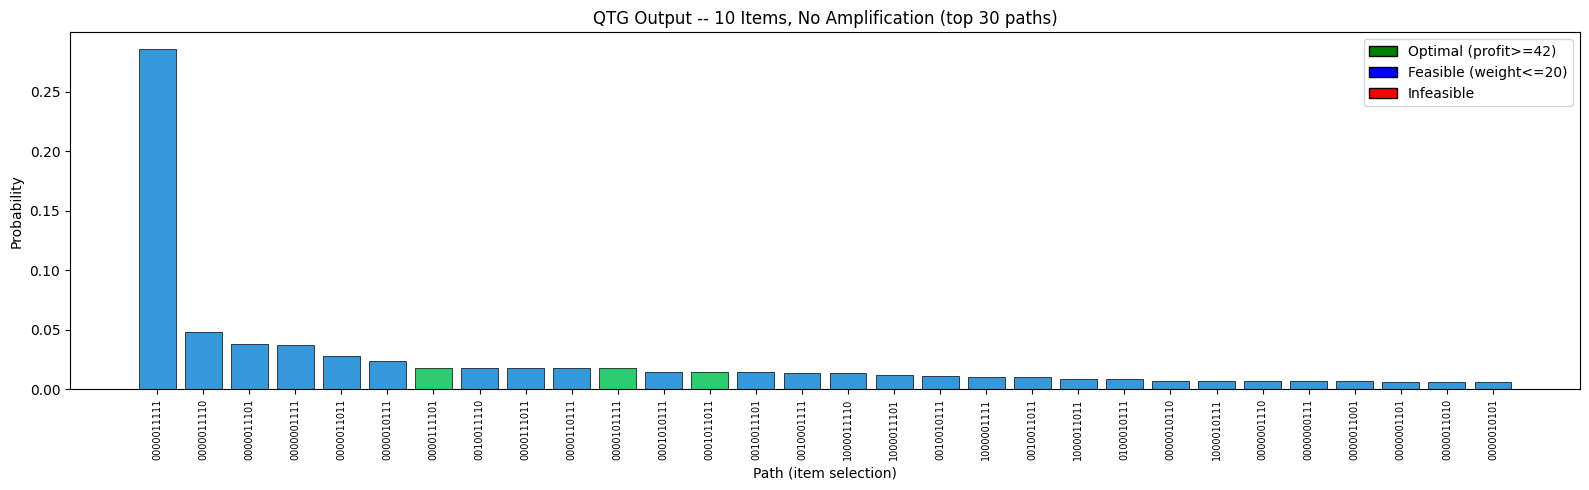

In [10]:
# ============================================================
# Cell 10 -- Histogram of bare QTG
# ============================================================

def color_bar(label, weights, profits, n_items, capacity, threshold):
    tw = sum(weights[i] for i in range(n_items) if label[n_items-1-i]=='1')
    tp = sum(profits[i] for i in range(n_items) if label[n_items-1-i]=='1')
    if tp >= threshold and tw <= capacity: return '#2ecc71'
    elif tw <= capacity:                  return '#3498db'
    else:                                 return '#e74c3c'

# With 10 items there are 1024 paths -- only show the top 30 by probability
labels = sorted(path_probs.keys(), key=lambda x: -path_probs[x])[:30]
colors = [color_bar(l, weights, profits, n_items, capacity, threshold)
          for l in labels]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(labels)), [path_probs.get(l,0) for l in labels],
       color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_xlabel('Path (item selection)')
ax.set_ylabel('Probability')
ax.set_title('QTG Output -- 10 Items, No Amplification (top 30 paths)')
ax.legend(handles=[
    Patch(facecolor='green', edgecolor='black', label=f'Optimal (profit>={threshold})'),
    Patch(facecolor='blue', edgecolor='black', label=f'Feasible (weight<={capacity})'),
    Patch(facecolor='red', edgecolor='black', label='Infeasible'),
], loc='upper right')
plt.tight_layout()
plt.show()


## Part B -- Amplitude amplification with multiple Grover iterations

sweep from 0 to 5 Grover iterations to see how the probability
of the optimal solution evolves. For this 10-item instance (367 feasible states,
1 marked optimal), the theoretical optimum is around k ≈ floor(π/4 × √367) ≈ 15,
but we test k=0..5 to observe the amplification trend.





In [11]:
# ============================================================
# Cell 11 -- Build amplified circuit with k Grover iterations
# ============================================================
#
# For k iterations the circuit structure is:
#
#   QTG -> [ Oracle -> QTG^dag -> S_0 -> QTG ] x k -> Measure
#
# k=0 is just the bare QTG (no amplification).

def build_amplified_circuit(k_iters, qtg_circ, n_items, n_cap,
                            n_prof, capacity, threshold):
    """Return a measurement-ready circuit with k Grover iterations."""

    path_reg = QuantumRegister(n_items, 'path')
    cap_reg  = QuantumRegister(n_cap,   'cap')
    prof_reg = QuantumRegister(n_prof,  'prof')
    anc_reg  = QuantumRegister(1,       'anc')
    c_path   = ClassicalRegister(n_items, 'c_path')
    c_prof   = ClassicalRegister(n_prof,  'c_prof')

    qc = QuantumCircuit(path_reg, cap_reg, prof_reg, anc_reg,
                        c_path, c_prof)

    # qubit index lists
    all_q   = list(range(n_items + n_cap + n_prof + 1))
    prof_q  = list(range(n_items + n_cap, n_items + n_cap + n_prof))
    anc_idx = n_items + n_cap + n_prof

    # gates
    qtg_gate = qtg_circ.to_gate(label='QTG')
    qtg_inv  = qtg_gate.inverse()
    qtg_inv.label = 'QTG_dag'

    # Step 1: initial QTG
    qc.append(qtg_gate, all_q)

    # Steps 2-5: repeat k times
    for _ in range(k_iters):
        qc.barrier()
        # Oracle: phase-flip states with profit >= threshold
        threshold_oracle(qc, prof_q, anc_idx, threshold, n_prof)
        qc.barrier()
        # QTG^dag: undo state preparation
        qc.append(qtg_inv, all_q)
        qc.barrier()
        # Reflect about |0...0>  
        reflect_zero(qc, all_q)
        qc.barrier()
        # QTG: redo state preparation
        qc.append(qtg_gate, all_q)

    # Measure
    qc.measure(path_reg, c_path)
    qc.measure(prof_reg, c_prof)

    return qc

print('build_amplified_circuit() defined.')

build_amplified_circuit() defined.


In [12]:
# ============================================================
# Cell 12 -- Sweep over Grover iterations 0..5
# ============================================================

max_iters = 5
shots = 50000
sampler = AerSampler()

all_path_probs = {}   # k -> {path_bitstring: probability}

for k in range(max_iters + 1):
    print(f'Running k={k} ...', end=' ')
    qc_k = build_amplified_circuit(k, qtg_circ, n_items, n_cap,
                                   n_prof, capacity, threshold)
    job_k = sampler.run([qc_k], shots=shots)
    counts_k = job_k.result().quasi_dists[0].binary_probabilities()

    pp = {}
    for bitstr, prob in counts_k.items():
        path_bits = bitstr[n_prof:]
        pp[path_bits] = pp.get(path_bits, 0) + prob

    all_path_probs[k] = pp

    opt_prob = pp.get(optimal_bitstr, 0)
    greedy_prob = pp.get(greedy_bitstr, 0)
    print(f'P(optimal {optimal_bitstr}) = {opt_prob:.4f},  '
          f'P(greedy {greedy_bitstr}) = {greedy_prob:.4f}')

print('\nSweep complete.')



Running k=0 ... P(optimal 0000101111) = 0.0179,  P(greedy 0000011111) = 0.2815
Running k=1 ... P(optimal 0000101111) = 0.1419,  P(greedy 0000011111) = 0.1836
Running k=2 ... P(optimal 0000101111) = 0.2923,  P(greedy 0000011111) = 0.0572
Running k=3 ... P(optimal 0000101111) = 0.3586,  P(greedy 0000011111) = 0.0000
Running k=4 ... P(optimal 0000101111) = 0.2892,  P(greedy 0000011111) = 0.0596
Running k=5 ... P(optimal 0000101111) = 0.1364,  P(greedy 0000011111) = 0.1874

Sweep complete.


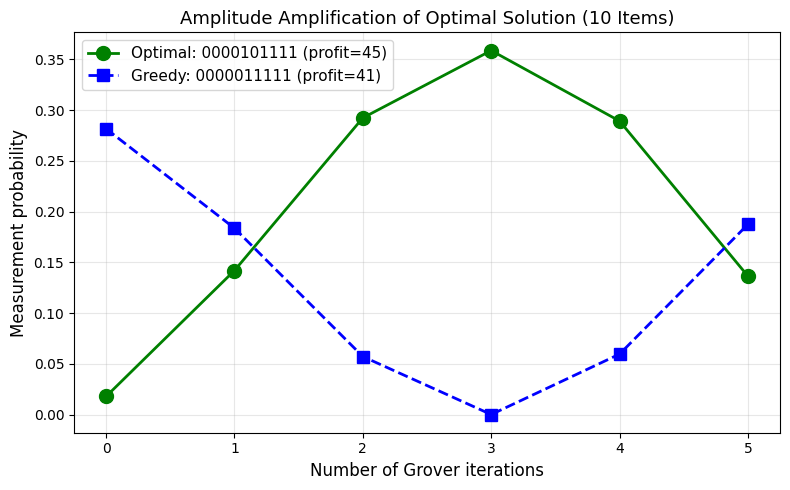

In [13]:
# ============================================================
# Cell 13 -- Plot: probability of optimal vs iterations
# ============================================================

ks = list(range(max_iters + 1))
opt_probs = [all_path_probs[k].get(optimal_bitstr, 0) for k in ks]
greedy_probs = [all_path_probs[k].get(greedy_bitstr, 0) for k in ks]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, opt_probs, 'go-', markersize=10, linewidth=2,
        label=f'Optimal: {optimal_bitstr} (profit=45)')
ax.plot(ks, greedy_probs, 'bs--', markersize=8, linewidth=2,
        label=f'Greedy: {greedy_bitstr} (profit=41)')
ax.set_xlabel('Number of Grover iterations', fontsize=12)
ax.set_ylabel('Measurement probability', fontsize=12)
ax.set_title('Amplitude Amplification of Optimal Solution (10 Items)', fontsize=13)
ax.set_xticks(ks)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


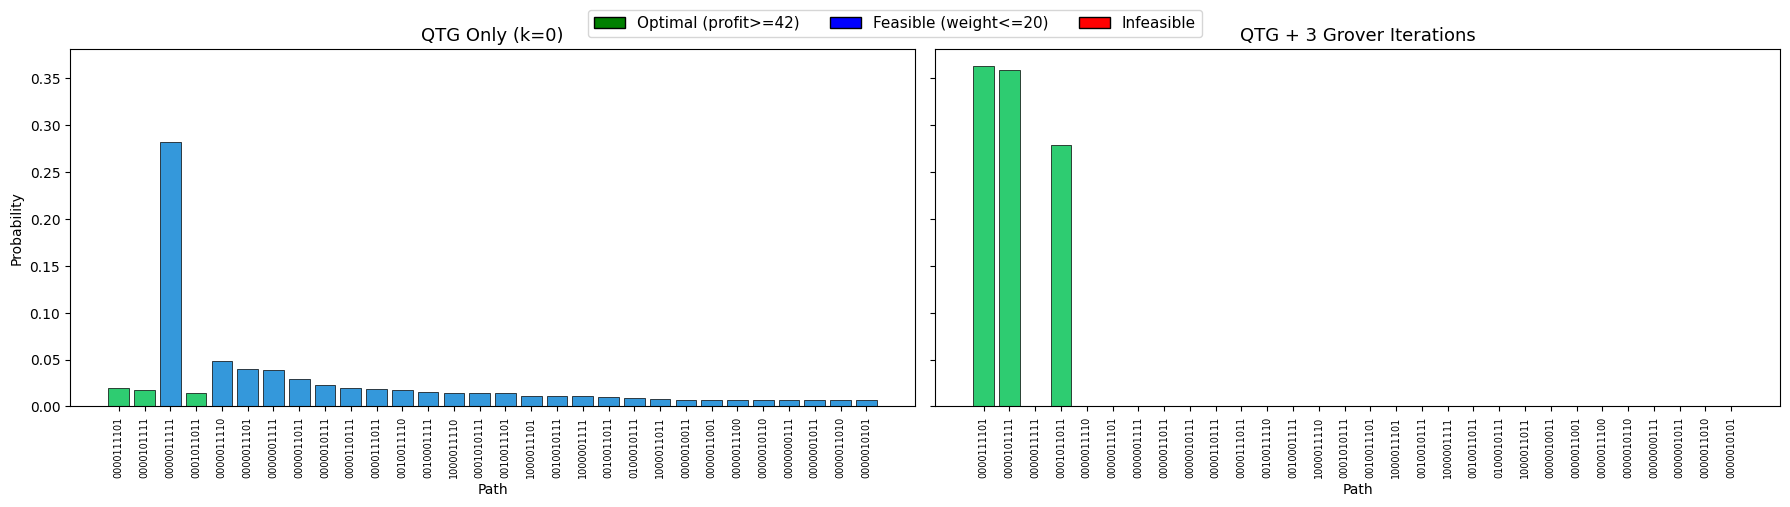

Best iteration count: k=3


In [14]:
# ============================================================
# Cell 14 -- Side-by-side: k=0 vs best k
# ============================================================

best_k = max(range(max_iters+1),
             key=lambda k: all_path_probs[k].get(optimal_bitstr, 0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

# With 1024 paths, only show top 30 by combined probability
all_labels_set = set()
for pp in all_path_probs.values():
    all_labels_set.update(pp.keys())
# Pick top 30 by max probability across all k
all_labels = sorted(all_labels_set,
                    key=lambda l: max(all_path_probs[k].get(l, 0)
                                      for k in all_path_probs),
                    reverse=True)[:30]
colors = [color_bar(l, weights, profits, n_items, capacity, threshold)
          for l in all_labels]

# Left: k=0 (bare QTG)
p0 = [all_path_probs[0].get(l, 0) for l in all_labels]
ax1.bar(range(len(all_labels)), p0, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_xticks(range(len(all_labels)))
ax1.set_xticklabels(all_labels, rotation=90, fontsize=7)
ax1.set_title('QTG Only (k=0)', fontsize=13)
ax1.set_xlabel('Path')
ax1.set_ylabel('Probability')

# Right: best k
pb = [all_path_probs[best_k].get(l, 0) for l in all_labels]
ax2.bar(range(len(all_labels)), pb, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_xticks(range(len(all_labels)))
ax2.set_xticklabels(all_labels, rotation=90, fontsize=7)
ax2.set_title(f'QTG + {best_k} Grover Iterations', fontsize=13)
ax2.set_xlabel('Path')

fig.legend(handles=[
    Patch(facecolor='green', edgecolor='black', label=f'Optimal (profit>={threshold})'),
    Patch(facecolor='blue', edgecolor='black', label=f'Feasible (weight<={capacity})'),
    Patch(facecolor='red', edgecolor='black', label='Infeasible'),
], loc='upper center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

print(f'Best iteration count: k={best_k}')


In [15]:
# ============================================================
# Cell 15 — Classical brute-force solver
# ============================================================
#
# Enumerate all 2^n subsets.  For each, check if total weight
# <= capacity.  If feasible and profit is best so far, update.
#
# This is O(2^n) — exponential.  It becomes slow around n=25
# and completely infeasible around n=30.

import time

def brute_force_knapsack(weights, profits, capacity):
    """Solve 0-1 knapsack by exhaustive enumeration.
    Returns (best_profit, best_items, n_feasible, elapsed_seconds)."""
    n = len(weights)
    best_profit = 0
    best_items = []
    n_feasible = 0

    t0 = time.perf_counter()

    for mask in range(2**n):             # iterate over all 2^n subsets
        tw = 0
        tp = 0
        items = []
        for i in range(n):               # check each item
            if (mask >> i) & 1:           # item i is included
                tw += weights[i]
                tp += profits[i]
                items.append(i)
        if tw <= capacity:               # feasibility check
            n_feasible += 1
            if tp > best_profit:         # update best
                best_profit = tp
                best_items = items

    elapsed = time.perf_counter() - t0
    return best_profit, best_items, n_feasible, elapsed

# Test on our 4-item instance
bp, bi, nf, et = brute_force_knapsack(weights, profits, capacity)
print(f'Brute force result for {n_items}-item instance:')
print(f'  Best profit:      {bp}')
print(f'  Items selected:   {bi}')
print(f'  Feasible subsets: {nf} / {2**n_items}')
print(f'  Time:             {et:.6f} seconds')
print(f'  Operations:       {2**n_items:,}')

Brute force result for 10-item instance:
  Best profit:      45
  Items selected:   [0, 1, 2, 3, 5]
  Feasible subsets: 367 / 1024
  Time:             0.002403 seconds
  Operations:       1,024


In [16]:
# ============================================================
# Cell 16 — Test case generator
# ============================================================
#
# Generates random knapsack instances of varying size.
# Items are sorted by decreasing density (paper's preprocessing).
# Capacity is set to ~40% of total weight so that roughly half
# the items can fit, making the problem non-trivial.

import random
import math

def generate_instance(n, seed=None):
    """Generate a random n-item 0-1 knapsack instance.
    Returns (weights, profits, capacity, greedy_sol, greedy_profit)."""
    rng = random.Random(seed)

    # Generate items with random weights and profits
    items = []
    for _ in range(n):
        w = rng.randint(1, 20)
        p = rng.randint(1, 20)
        items.append((w, p))

    # Sort by decreasing density (profit/weight)
    items.sort(key=lambda x: x[1]/x[0], reverse=True)

    ws = [x[0] for x in items]
    ps = [x[1] for x in items]

    # Capacity = ~40% of total weight
    cap = int(0.4 * sum(ws))
    if cap < max(ws):
        cap = max(ws) + 1  # ensure at least 1 item fits

    # Greedy solution
    greedy = [0] * n
    remaining = cap
    gp = 0
    for i in range(n):
        if ws[i] <= remaining:
            greedy[i] = 1
            remaining -= ws[i]
            gp += ps[i]

    # Register sizes
    n_cap  = math.floor(math.log2(cap)) + 2     # +2 for sign bit safety
    max_p  = sum(ps)
    n_prof = math.floor(math.log2(max_p)) + 2

    return {
        'n': n, 'weights': ws, 'profits': ps, 'capacity': cap,
        'greedy_solution': greedy, 'greedy_profit': gp,
        'n_cap': n_cap, 'n_prof': n_prof,
        'total_qubits': n + n_cap + n_prof + 1
    }

# Show a sample
inst = generate_instance(6, seed=42)
print(f"Sample 6-item instance:")
print(f"  weights:  {inst['weights']}")
print(f"  profits:  {inst['profits']}")
print(f"  capacity: {inst['capacity']}")
print(f"  greedy:   {inst['greedy_solution']} (profit={inst['greedy_profit']})")
print(f"  qubits:   {inst['total_qubits']}")

Sample 6-item instance:
  weights:  [3, 4, 9, 8, 4, 14]
  profits:  [19, 18, 8, 5, 1, 2]
  capacity: 16
  greedy:   [1, 1, 1, 0, 0, 0] (profit=45)
  qubits:   20


In [17]:
# ============================================================
# Cell 17 — Run brute force across multiple sizes
# ============================================================
#
# We test n = 4, 6, 8, 10, 12, 15, 18, 20.
# Brute force is feasible for all of these (2^20 = 1M subsets).
# We also record the optimal profit and number of feasible
# solutions, which we'll need for the quantum estimate.

test_sizes = [4, 6, 8, 10, 12, 15, 18, 20]

bf_results = {}   # n -> {profit, time, n_feasible, n_optimal, ...}

print(f'{"n":>4} {"2^n":>10} {"Feasible":>10} {"Optimal":>8} '
      f'{"BF time(s)":>12} {"Qubits":>8}')
print('-' * 62)

for n in test_sizes:
    inst = generate_instance(n, seed=42)
    bp, bi, nf, et = brute_force_knapsack(
        inst['weights'], inst['profits'], inst['capacity'])

    # Count how many subsets achieve the optimal profit
    n_opt = 0
    for mask in range(2**n):
        tw = sum(inst['weights'][i] for i in range(n) if (mask>>i)&1)
        tp = sum(inst['profits'][i] for i in range(n) if (mask>>i)&1)
        if tw <= inst['capacity'] and tp == bp:
            n_opt += 1

    bf_results[n] = {
        'instance': inst,
        'optimal_profit': bp,
        'optimal_items': bi,
        'n_feasible': nf,
        'n_optimal': n_opt,
        'bf_time': et,
    }

    print(f'{n:>4} {2**n:>10,} {nf:>10,} {bp:>8} '
          f'{et:>12.6f} {inst["total_qubits"]:>8}')

print('\nBrute force complete for all sizes.')

   n        2^n   Feasible  Optimal   BF time(s)   Qubits
--------------------------------------------------------------
   4         16          6       19     0.000068       17
   6         64         22       45     0.000113       20
   8        256         88       49     0.000550       23
  10      1,024        332       78     0.004247       25
  12      4,096      1,187       96     0.012583       29
  15     32,768      8,522      118     0.094189       32
  18    262,144     62,299      133     0.849147       35
  20  1,048,576    242,926      154     3.549681       37

Brute force complete for all sizes.


In [18]:
# ============================================================
# Cell 18 — Estimate quantum cycles for each instance
# ============================================================
#
# Since we cannot run 2077-qubit circuits on a simulator, we
# Estimate the quantum runtime using the paper's model:
#
#   quantum_cycles = depth_per_run × expected_repetitions
#
# where:
#   depth_per_run = (2k+1) × QTG_depth + k × (oracle_depth + S0_depth)
#   expected_repetitions = 1 / P(optimal)
#
# The optimal number of Grover iterations is:
#   k_opt ≈ (pi/4) × sqrt(N_feasible / N_optimal)
#
# At k_opt, P(optimal) ≈ 1 (or close to it), so expected_reps ≈ 1.
#
# For the QTG depth per layer, the paper shows it's O(n) because
# each item adds a constant number of gates.  For our Qiskit
# implementation, we measure it directly for small n and
# extrapolate for larger n.
#
# For brute force, the "cycle count" is simply 2^n × n
# (2^n subsets, each requiring n additions to compute weight/profit).

from qiskit import transpile

# First, measure actual QTG depth for small instances to get
# the depth-per-item scaling constant.
calibration_sizes = [4, 6, 8, 10, 12, 15, 18, 20]
depth_data = []

print('Calibrating QTG depth per item...')
print(f'{"n":>4} {"Qubits":>7} {"QTG depth":>10} {"Per item":>10}')
print('-' * 36)

for n in calibration_sizes:
    inst = generate_instance(n, seed=42)

    # Build QTG for this instance
    cal_qtg = build_qtg(inst['n'], inst['weights'], inst['profits'],
                        inst['capacity'], inst['n_cap'], inst['n_prof'],
                        inst['greedy_solution'], inst['n']/4)

    # Transpile to basis gates and measure depth
    cal_t = transpile(cal_qtg, basis_gates=['cx', 'u', 'id'],
                      optimization_level=2)
    d = cal_t.depth()
    depth_data.append((n, d))
    print(f'{n:>4} {inst["total_qubits"]:>7} {d:>10} {d/n:>10.1f}')

# Linear fit: depth ≈ alpha × n
alpha = np.mean([d/n for n, d in depth_data])
print(f'\nDepth per item (alpha): ~{alpha:.0f} basis-gate layers')

Calibrating QTG depth per item...
   n  Qubits  QTG depth   Per item
------------------------------------
   4      17        946      236.5
   6      20       1889      314.8
   8      23       2537      317.1
  10      25       3177      317.7
  12      29       4771      397.6
  15      32       5964      397.6
  18      35       7164      398.0
  20      37       7946      397.3

Depth per item (alpha): ~347 basis-gate layers


In [19]:
# ============================================================
# Cell 19 — Compute estimated quantum cycles for all sizes
# ============================================================
#
# For each test size n:
#
#   QTG_depth ≈ alpha × n            (from calibration)
#   k_opt = floor(pi/4 × sqrt(N_feasible / N_optimal))
#   grover_depth = (2*k_opt + 1) × QTG_depth   (simplified)
#   expected_reps ≈ 1  at k_opt      (Grover hits ~100%)
#   quantum_cycles = grover_depth
#
#   BF_cycles = 2^n × n              (n additions per subset)

print(f'{"n":>4} {"BF cycles":>14} {"BF time(s)":>12} '
      f'{"k_opt":>6} {"QTG cycles":>14} {"Speedup":>10}')
print('-' * 72)

comparison = {}  # n -> (bf_cycles, qtg_cycles)

for n in test_sizes:
    r = bf_results[n]
    inst = r['instance']

    # Classical brute force cycles
    bf_cycles = (2**n) * n   # n ops per subset

    # Quantum estimate
    nf = r['n_feasible']
    no = max(r['n_optimal'], 1)
    k_opt = max(1, int((np.pi / 4) * np.sqrt(nf / no)))

    qtg_depth = alpha * n
    # Full Grover circuit: (2k+1) QTG applications + k oracle/reflection
    # Oracle and reflection have roughly the same depth as one QTG
    total_depth = (2 * k_opt + 1) * qtg_depth + k_opt * qtg_depth
    # = (3*k_opt + 1) * qtg_depth
    qtg_cycles = int(total_depth)

    speedup = bf_cycles / qtg_cycles if qtg_cycles > 0 else 0

    comparison[n] = (bf_cycles, qtg_cycles, k_opt)

    print(f'{n:>4} {bf_cycles:>14,} {r["bf_time"]:>12.6f} '
          f'{k_opt:>6} {qtg_cycles:>14,} {speedup:>10.1f}x')

   n      BF cycles   BF time(s)  k_opt     QTG cycles    Speedup
------------------------------------------------------------------------
   4             64     0.000068      1          5,553        0.0x
   6            384     0.000113      3         20,824        0.0x
   8          2,048     0.000550      7         61,086        0.0x
  10         10,240     0.004247     14        149,244        0.1x
  12         49,152     0.012583     27        341,526        0.1x
  15        491,520     0.094189     72      1,129,746        0.4x
  18      4,718,592     0.849147    196      3,679,744        1.3x
  20     20,971,520     3.549681    387      8,066,144        2.6x


In [20]:
# ============================================================
# Cell 20 — larger instances
# ============================================================
#
# We can't simulate n=50 or n=100 on a classical computer,
# but we CAN compute the estimated cycle counts because
# the formulas only need n and the ratio N_feasible/N_optimal.
#
# Assumption: roughly 30% of subsets are feasible (typical for
# our instances), and there's 1 optimal solution.

print(f'{"n":>5} {"BF cycles":>18} {"QTG cycles":>18} {"Speedup":>12}')
print('-' * 58)

extended_sizes = [4, 8, 12, 16, 20, 30, 50, 75, 100, 200, 500]

bf_ext = []
qtg_ext = []

for n in extended_sizes:
    # BF cycles
    bf_c = (2**n) * n

    # QTG estimate
    # Assume N_feasible ≈ 0.3 × 2^n,  N_optimal = 1
    nf_est = max(1, int(0.3 * 2**min(n, 60)))  # cap to avoid overflow
    k_opt = max(1, int((np.pi / 4) * np.sqrt(nf_est)))
    qtg_depth = alpha * n
    qtg_c = int((3 * k_opt + 1) * qtg_depth)

    bf_ext.append(bf_c)
    qtg_ext.append(qtg_c)

    # For display, use log10 for huge numbers
    if bf_c > 1e15:
        bf_str = f'2^{n}*{n}'
        speedup_str = f'~2^{n//2}'
    else:
        bf_str = f'{bf_c:>18,}'
        speedup_str = f'{bf_c/qtg_c:>12.0f}x'

    print(f'{n:>5} {bf_str:>18} {qtg_c:>18,} {speedup_str:>12}')

    n          BF cycles         QTG cycles      Speedup
----------------------------------------------------------
    4                 64              5,553            0x
    8              2,048             52,756            0x
   12             49,152            341,526            0x
   16          1,048,576          1,838,136            1x
   20         20,971,520          9,169,859            2x
   30     32,212,254,720        440,330,247           73x
   50            2^50*50    751,487,064,640        ~2^25
   75            2^75*75 36,071,379,076,723        ~2^37
  100          2^100*100 48,095,172,102,298        ~2^50
  200          2^200*200 96,190,344,204,597       ~2^100
  500          2^500*500 240,475,860,511,493       ~2^250
